<a href="https://colab.research.google.com/github/shubhamgarg190110/SP_500_Research_Project/blob/main/sp500_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

## 1. Read in the dataset

In [2]:
url = "https://raw.githubusercontent.com/shubhamgarg190110/SP_500_Research_Project/refs/heads/main/sp500.csv"
local_file = Path("sp500.csv")

if local_file.exists():
    raw_df = pd.read_csv(local_file)
else:
    raw_df = pd.read_csv(url)

print(f"Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
raw_df.head()


Raw shape: 1,865 rows × 10 columns


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


## 2. Inspect the raw data

In [3]:
raw_df.info()

raw_quality = pd.DataFrame({
    "data_type": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(2),
    "unique_values": raw_df.nunique(dropna=False)
})
raw_quality


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1865 non-null   object 
 1   SP500                 1865 non-null   float64
 2   Dividend              1865 non-null   float64
 3   Earnings              1865 non-null   float64
 4   Consumer Price Index  1865 non-null   float64
 5   Long Interest Rate    1865 non-null   float64
 6   Real Price            1865 non-null   float64
 7   Real Dividend         1865 non-null   float64
 8   Real Earnings         1865 non-null   float64
 9   PE10                  1865 non-null   float64
dtypes: float64(9), object(1)
memory usage: 145.8+ KB


,data_type,missing_count,missing_percent,unique_values
Date,object,0,0.0,1865
SP500,float64,0,0.0,1494
Dividend,float64,0,0.0,1191
Earnings,float64,0,0.0,1389
Consumer Price Index,float64,0,0.0,889
Long Interest Rate,float64,0,0.0,649
Real Price,float64,0,0.0,1783
Real Dividend,float64,0,0.0,1254
Real Earnings,float64,0,0.0,1548
PE10,float64,0,0.0,1204


## 3. Clean column names and data types

In [4]:
df = raw_df.copy()

def clean_column_name(name):
    """Convert a column name to lowercase snake_case."""
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")

df.columns = [clean_column_name(col) for col in df.columns]

# Parse the monthly date variable.
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Coerce all remaining variables to numeric.
numeric_columns = df.columns.drop("date")
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

df.dtypes


,0
date,datetime64[ns]
sp500,float64
dividend,float64
earnings,float64
consumer_price_index,float64
long_interest_rate,float64
real_price,float64
real_dividend,float64
real_earnings,float64
pe10,float64


## 4. Handle duplicates and missing data

`PE10` is a valuation ratio and a value of zero is not meaningful here. The source uses zero as a placeholder during periods when PE10 is unavailable, so those zeros are converted to `NaN`.

The missing PE10 observations are retained as missing rather than interpolated because estimating a valuation ratio would introduce artificial data.

### Row removal

Rows 1–121 and rows 1832–1866 are removed using 1-based row numbering due to these rows containing missing data. Because the dataset contains 1,865 rows, the second range effectively removes rows 1832–1865.

In [5]:
# Remove specified rows using the original 1-based row numbering.
# Remove rows 1-121 and rows 1831-1866.
# Because the dataset has 1,865 rows, the second range ends at row 1,865.

rows_before = len(df)

positions_to_remove = set(range(0, min(121, rows_before)))
positions_to_remove.update(range(1830, min(1866, rows_before)))

row_mask = ~pd.Series(range(rows_before)).isin(positions_to_remove)
df = df.loc[row_mask.values].reset_index(drop=True)

print(f"Rows before removal: {rows_before}")
print(f"Rows removed: {rows_before - len(df)}")
print(f"Rows remaining: {len(df)}")


Rows before removal: 1865
Rows removed: 156
Rows remaining: 1709


## 5. Confirm tidy structure and data quality


In [6]:
clean_quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=False)
})

clean_quality

,data_type,missing_count,missing_percent,unique_values
date,datetime64[ns],0,0.0,1709
sp500,float64,0,0.0,1413
dividend,float64,0,0.0,1171
earnings,float64,0,0.0,1357
consumer_price_index,float64,0,0.0,860
long_interest_rate,float64,0,0.0,627
real_price,float64,0,0.0,1668
real_dividend,float64,0,0.0,1179
real_earnings,float64,0,0.0,1481
pe10,float64,0,0.0,1200


In [7]:
#%%
# Tidy-data checks:
# 1 row = 1 monthly observation
# 1 column = 1 variable
assert df.columns.is_unique, "Column names are not unique."
assert df["date"].is_unique, "There is more than one row for a month."
assert df["date"].is_monotonic_increasing, "Dates are not sorted."
assert not df.drop(columns="pe10").isna().any().any(), (
    "Unexpected missing values remain outside PE10."
)

expected_columns = [
    "date",
    "sp500",
    "dividend",
    "earnings",
    "consumer_price_index",
    "long_interest_rate",
    "real_price",
    "real_dividend",
    "real_earnings",
    "pe10",
]
assert df.columns.tolist() == expected_columns, "Unexpected columns or column order."

print(f"Clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("The dataset is tidy: each row is one month and each column is one variable.")

df.head()



Clean shape: 1,709 rows × 10 columns
Date range: 1881-02-01 to 2023-06-01
The dataset is tidy: each row is one month and each column is one variable.


,date,sp500,dividend,earnings,consumer_price_index,long_interest_rate,real_price,real_dividend,real_earnings,pe10
0,1881-02-01,6.17,0.270,0.4817,9.51,3.69,198.52,8.69,15.50,18.15
1,1881-03-01,6.24,0.275,0.4775,9.51,3.69,200.77,8.85,15.36,18.27
2,1881-04-01,6.22,0.280,0.4733,9.61,3.68,198.15,8.92,15.08,17.95
3,1881-05-01,6.50,0.285,0.4692,9.51,3.67,209.13,9.17,15.10,18.87
4,1881-06-01,6.58,0.290,0.4650,9.51,3.67,211.71,9.33,14.96,19.03


## 6. Save the cleaned dataset


In [8]:
output_file = Path("sp500_cleaned.csv")
df.to_csv(output_file, index=False, date_format="%Y-%m-%d")

print(f"Saved cleaned data to: {output_file.resolve()}")


Saved cleaned data to: /content/sp500_cleaned.csv


## 7. Data Visualizations

This section explores long-run patterns in prices, inflation, earnings, dividends, interest rates, valuation, and returns. Each chart is shown separately so it is easy to interpret and reuse in the final analysis.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Work from a visualization copy so the cleaned dataset remains unchanged.
viz_df = df.copy().sort_values("date").reset_index(drop=True)
viz_df["year"] = viz_df["date"].dt.year
viz_df["decade"] = (viz_df["year"] // 10) * 10

# Monthly and annual return measures used by later charts.
viz_df["monthly_nominal_return"] = viz_df["sp500"].pct_change()
viz_df["monthly_real_return"] = viz_df["real_price"].pct_change()
viz_df["annual_nominal_return"] = viz_df["sp500"].pct_change(12)
viz_df["annual_real_return"] = viz_df["real_price"].pct_change(12)
viz_df["rolling_10y_real_return"] = (
    (viz_df["real_price"] / viz_df["real_price"].shift(120)) ** (1 / 10) - 1
)

print(f"Visualization dataset: {len(viz_df):,} monthly observations")

Visualization dataset: 1,709 monthly observations


### 7.1 Nominal S&P 500 price over time


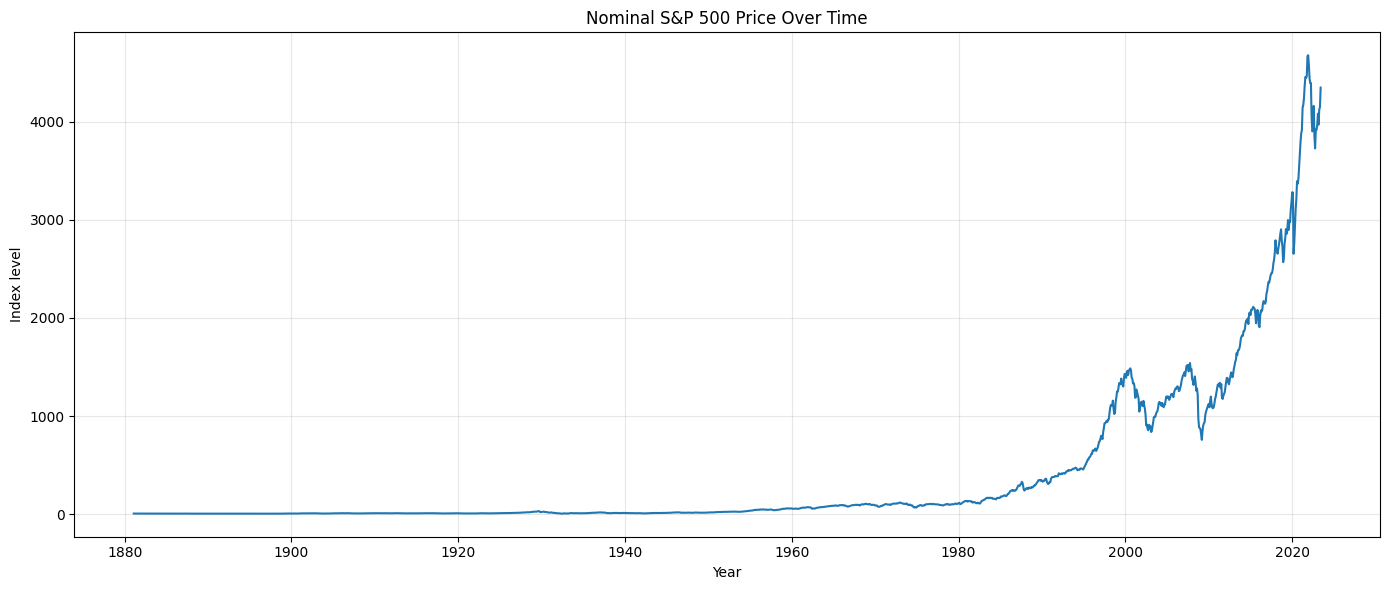

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["sp500"])
plt.title("Nominal S&P 500 Price Over Time")
plt.xlabel("Year")
plt.ylabel("Index level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Real S&P 500 price over time


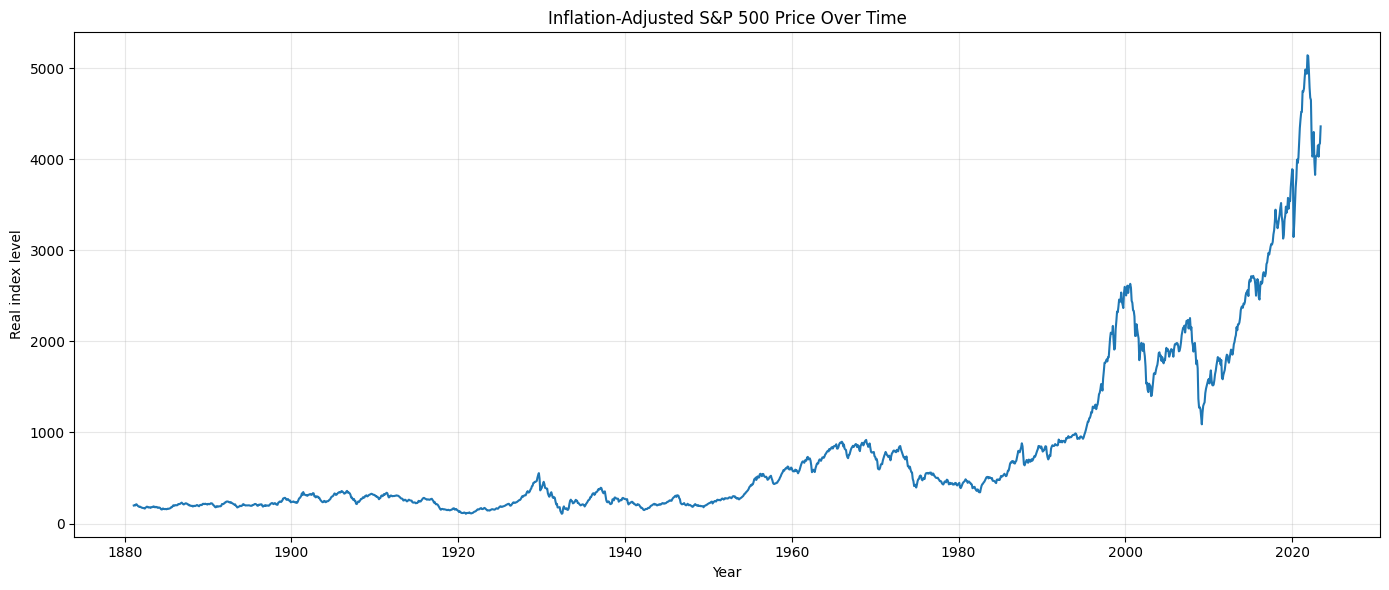

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["real_price"])
plt.title("Inflation-Adjusted S&P 500 Price Over Time")
plt.xlabel("Year")
plt.ylabel("Real index level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Nominal and real S&P 500 prices on a logarithmic scale


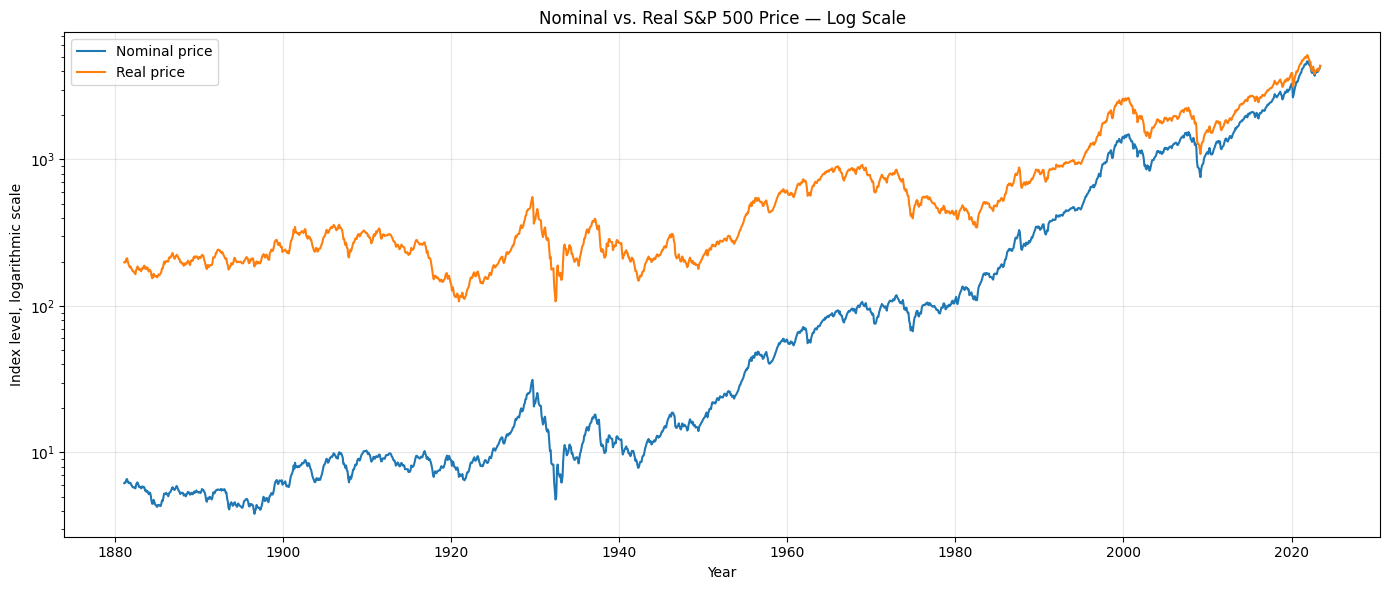

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["sp500"], label="Nominal price")
plt.plot(viz_df["date"], viz_df["real_price"], label="Real price")
plt.yscale("log")
plt.title("Nominal vs. Real S&P 500 Price — Log Scale")
plt.xlabel("Year")
plt.ylabel("Index level, logarithmic scale")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Consumer Price Index


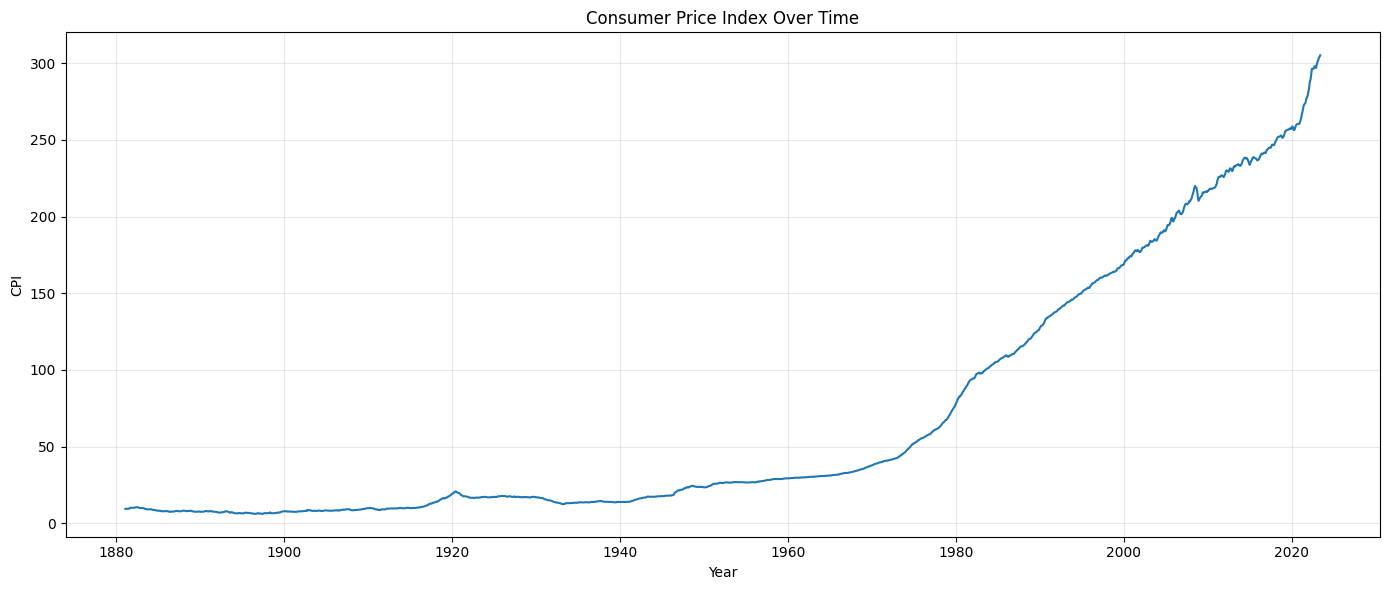

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["consumer_price_index"])
plt.title("Consumer Price Index Over Time")
plt.xlabel("Year")
plt.ylabel("CPI")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 Long-term interest rate


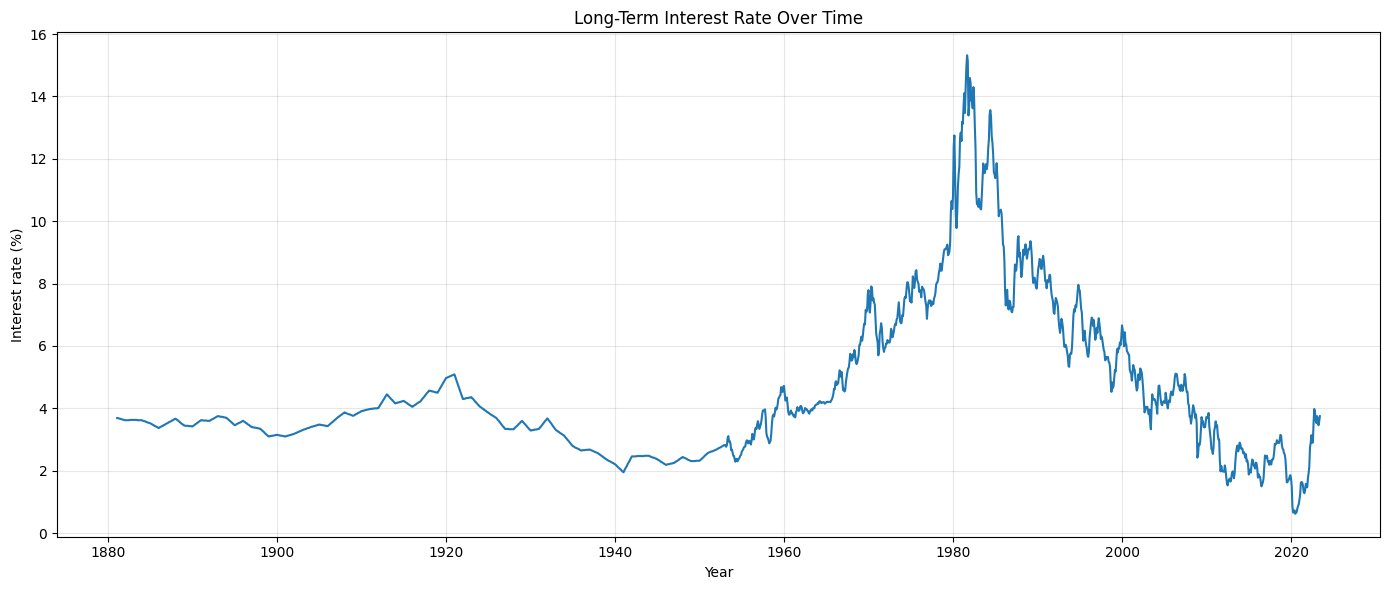

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["long_interest_rate"])
plt.title("Long-Term Interest Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Interest rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.6 Nominal dividends and earnings


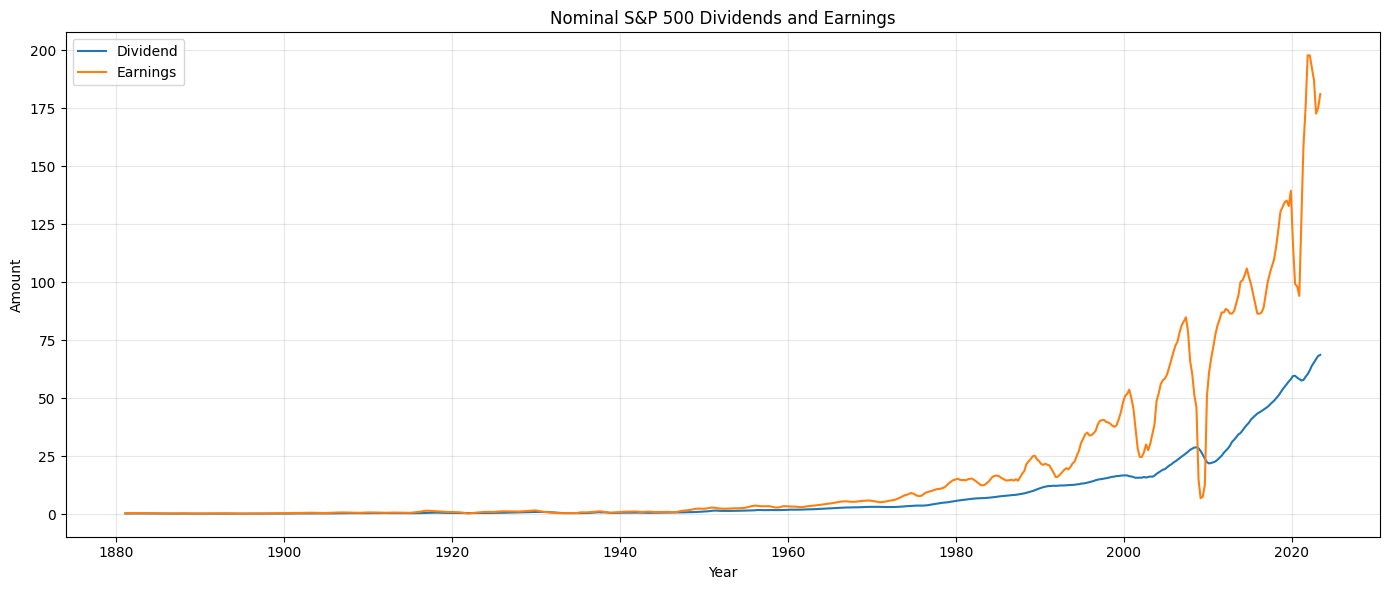

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["dividend"], label="Dividend")
plt.plot(viz_df["date"], viz_df["earnings"], label="Earnings")
plt.title("Nominal S&P 500 Dividends and Earnings")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### 7.7 Real dividends and real earnings


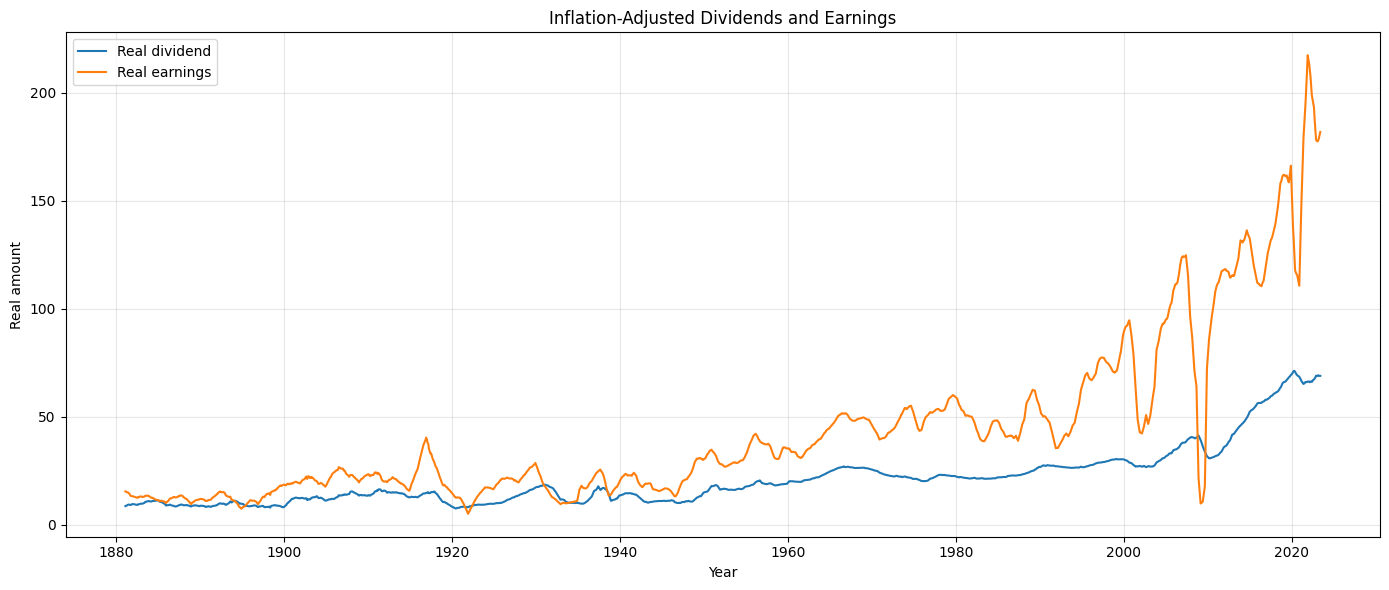

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["real_dividend"], label="Real dividend")
plt.plot(viz_df["date"], viz_df["real_earnings"], label="Real earnings")
plt.title("Inflation-Adjusted Dividends and Earnings")
plt.xlabel("Year")
plt.ylabel("Real amount")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.8 PE10 valuation ratio


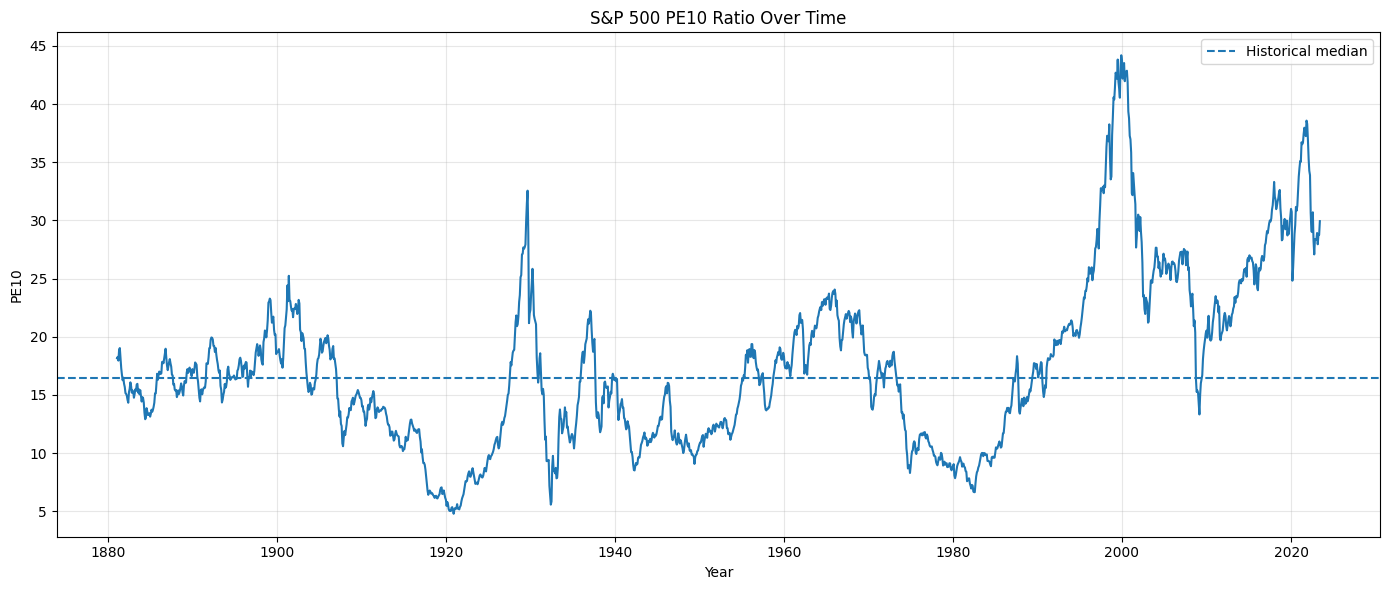

In [17]:
#%%
pe10_plot = viz_df.dropna(subset=["pe10"])
plt.figure(figsize=(14, 6))
plt.plot(pe10_plot["date"], pe10_plot["pe10"])
plt.axhline(pe10_plot["pe10"].median(), linestyle="--", label="Historical median")
plt.title("S&P 500 PE10 Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("PE10")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.9 Normalized comparison of major variables


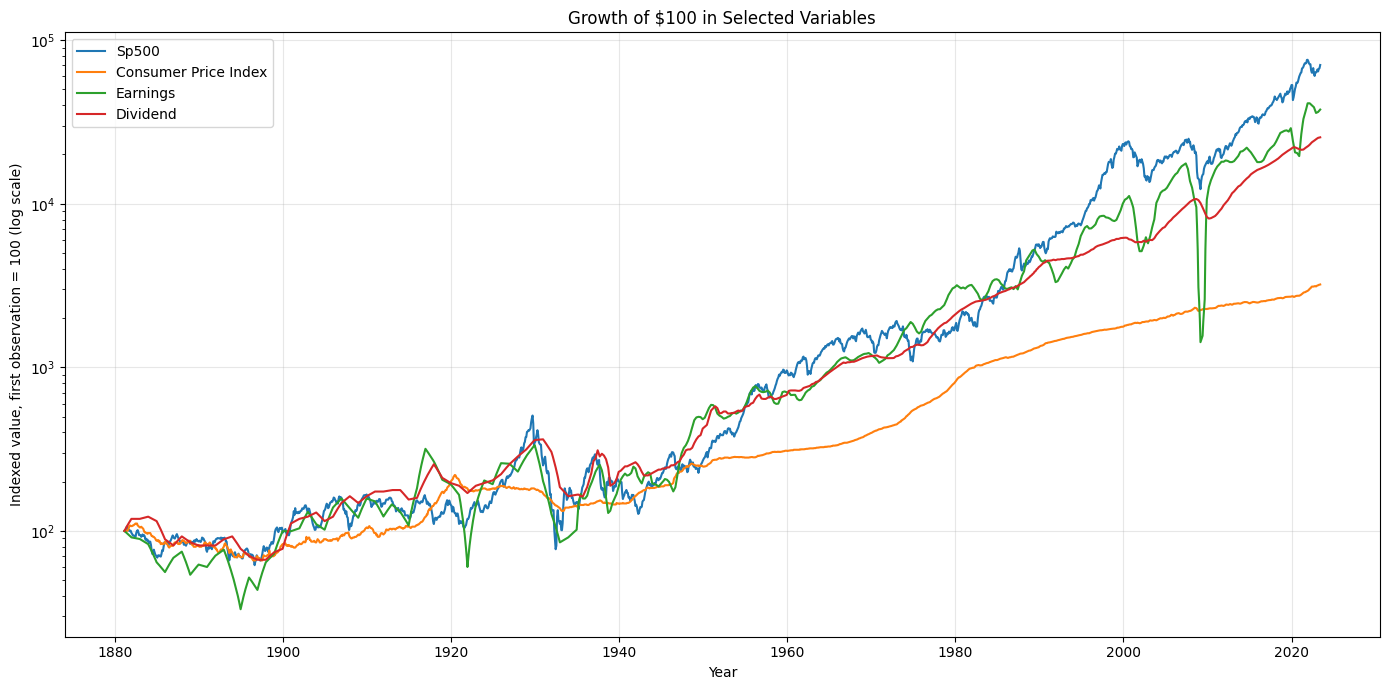

In [18]:
normalized = viz_df.set_index("date")[[
    "sp500", "consumer_price_index", "earnings", "dividend"
]].dropna()
normalized = normalized / normalized.iloc[0] * 100

plt.figure(figsize=(14, 7))
for column in normalized.columns:
    plt.plot(normalized.index, normalized[column], label=column.replace("_", " ").title())
plt.yscale("log")
plt.title("Growth of $100 in Selected Variables")
plt.xlabel("Year")
plt.ylabel("Indexed value, first observation = 100 (log scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.10 Distribution of monthly nominal returns


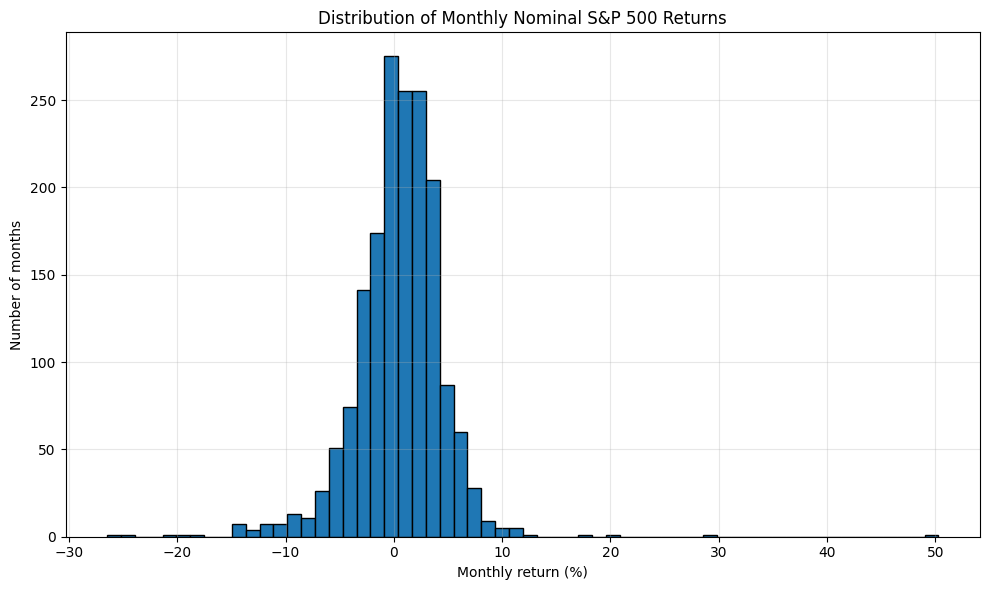

In [19]:
returns = viz_df["monthly_nominal_return"].dropna() * 100
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=60, edgecolor="black")
plt.title("Distribution of Monthly Nominal S&P 500 Returns")
plt.xlabel("Monthly return (%)")
plt.ylabel("Number of months")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.11 Distribution of annual real returns


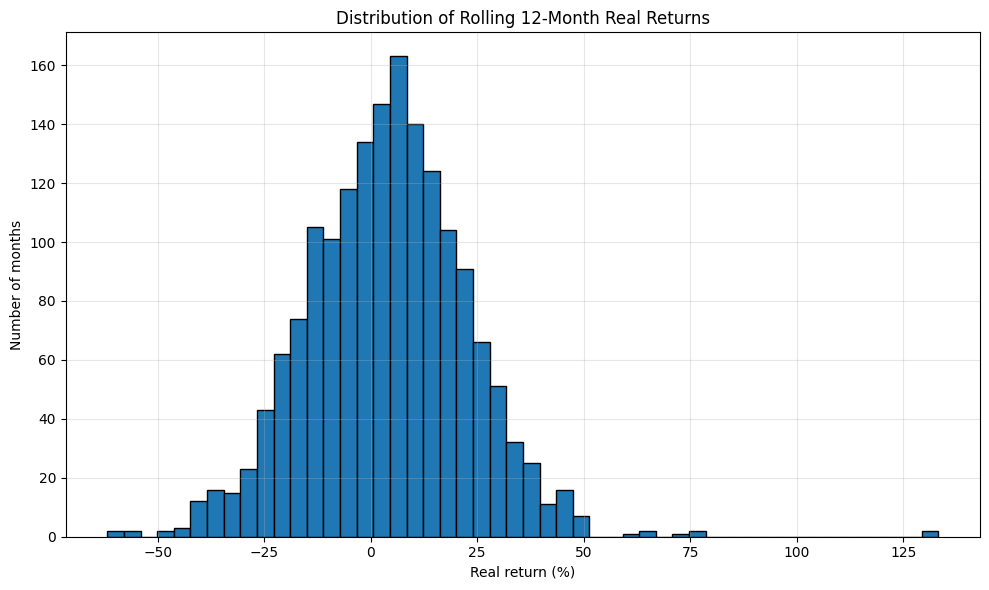

In [20]:
annual_real = viz_df["annual_real_return"].dropna() * 100
plt.figure(figsize=(10, 6))
plt.hist(annual_real, bins=50, edgecolor="black")
plt.title("Distribution of Rolling 12-Month Real Returns")
plt.xlabel("Real return (%)")
plt.ylabel("Number of months")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.12 Rolling 12-month nominal and real returns


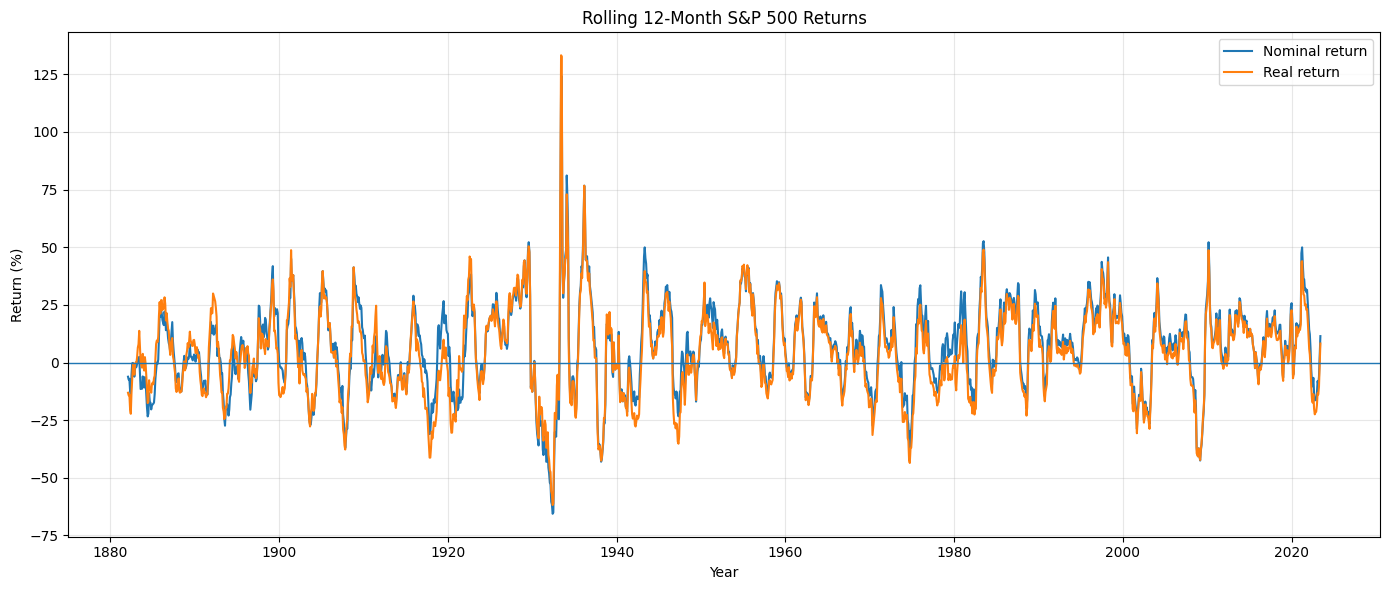

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["annual_nominal_return"] * 100, label="Nominal return")
plt.plot(viz_df["date"], viz_df["annual_real_return"] * 100, label="Real return")
plt.axhline(0, linewidth=1)
plt.title("Rolling 12-Month S&P 500 Returns")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.13 Rolling 10-year annualized real return


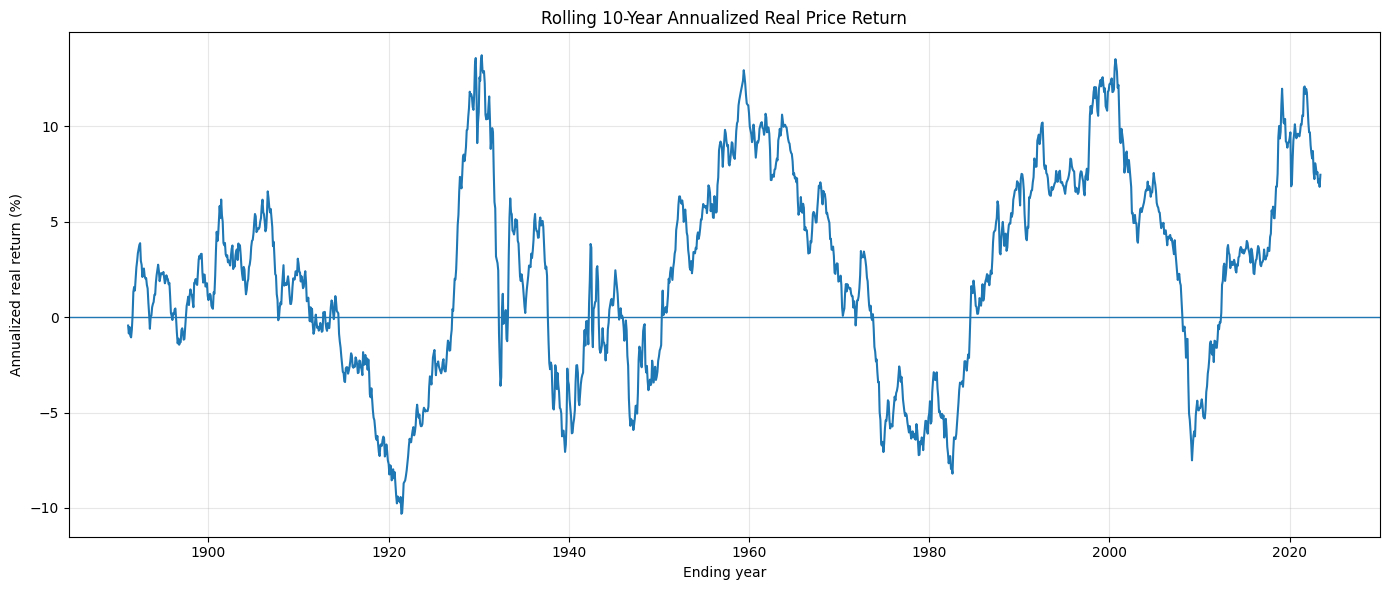

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(viz_df["date"], viz_df["rolling_10y_real_return"] * 100)
plt.axhline(0, linewidth=1)
plt.title("Rolling 10-Year Annualized Real Price Return")
plt.xlabel("Ending year")
plt.ylabel("Annualized real return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.14 Average annual real return by decade


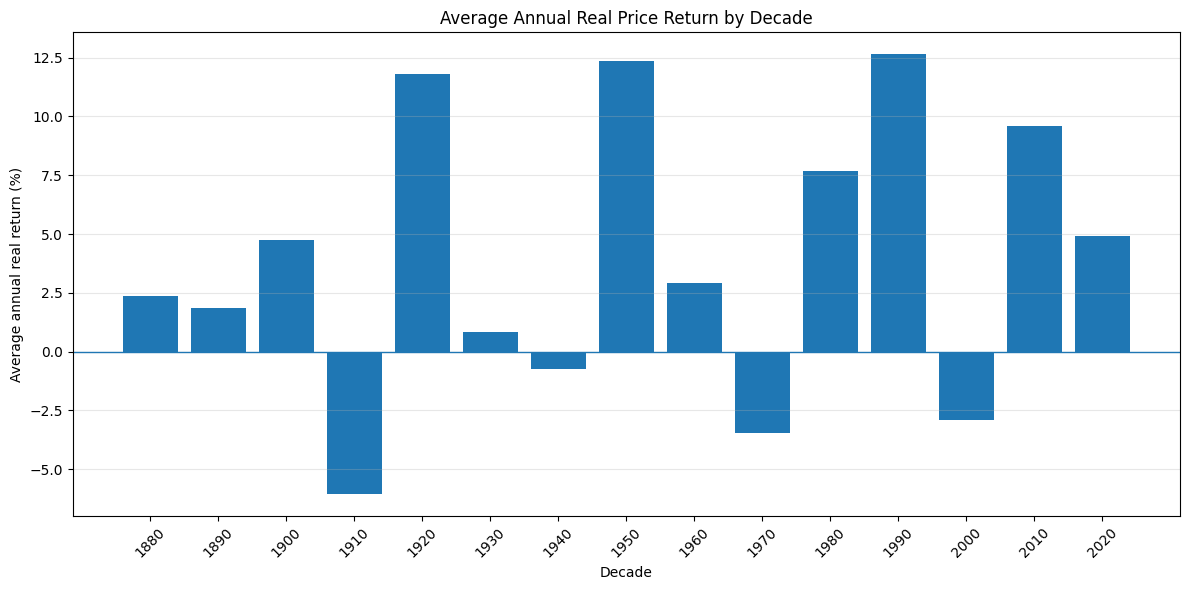

In [23]:
annual = (
    viz_df.set_index("date")["real_price"]
    .resample("YE")
    .last()
    .pct_change()
    .dropna()
    .rename("real_return")
    .reset_index()
)
annual["decade"] = (annual["date"].dt.year // 10) * 10
decade_returns = annual.groupby("decade")["real_return"].mean() * 100

plt.figure(figsize=(12, 6))
plt.bar(decade_returns.index.astype(str), decade_returns.values)
plt.axhline(0, linewidth=1)
plt.title("Average Annual Real Price Return by Decade")
plt.xlabel("Decade")
plt.ylabel("Average annual real return (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.15 Average PE10 by decade


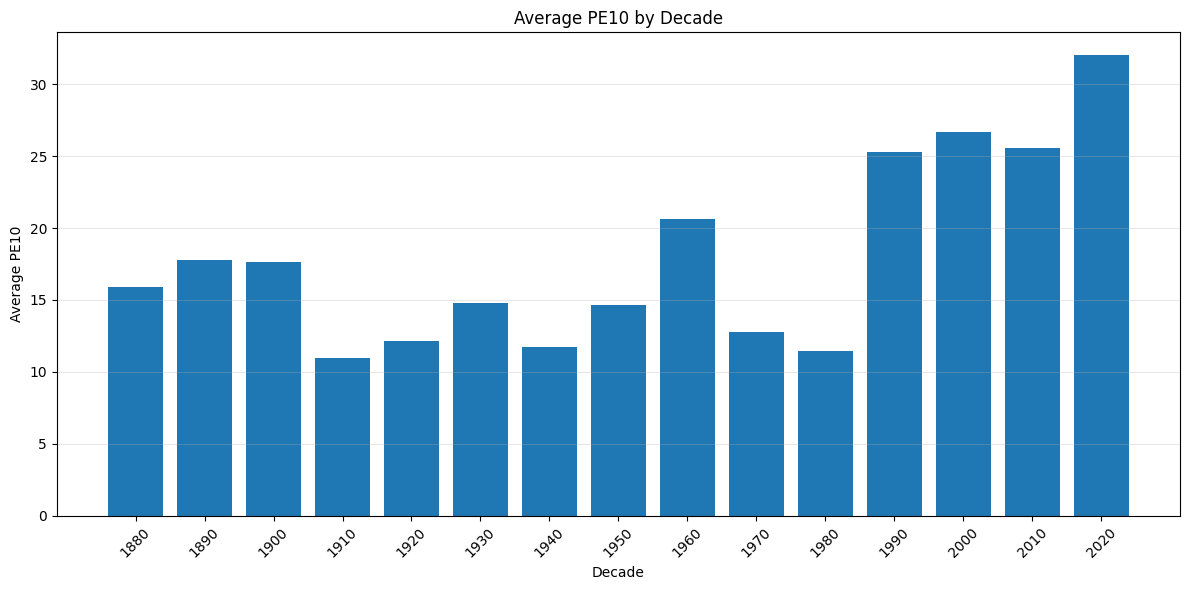

In [24]:
decade_pe10 = viz_df.dropna(subset=["pe10"]).groupby("decade")["pe10"].mean()

plt.figure(figsize=(12, 6))
plt.bar(decade_pe10.index.astype(str), decade_pe10.values)
plt.title("Average PE10 by Decade")
plt.xlabel("Decade")
plt.ylabel("Average PE10")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.16 PE10 versus subsequent 10-year real return


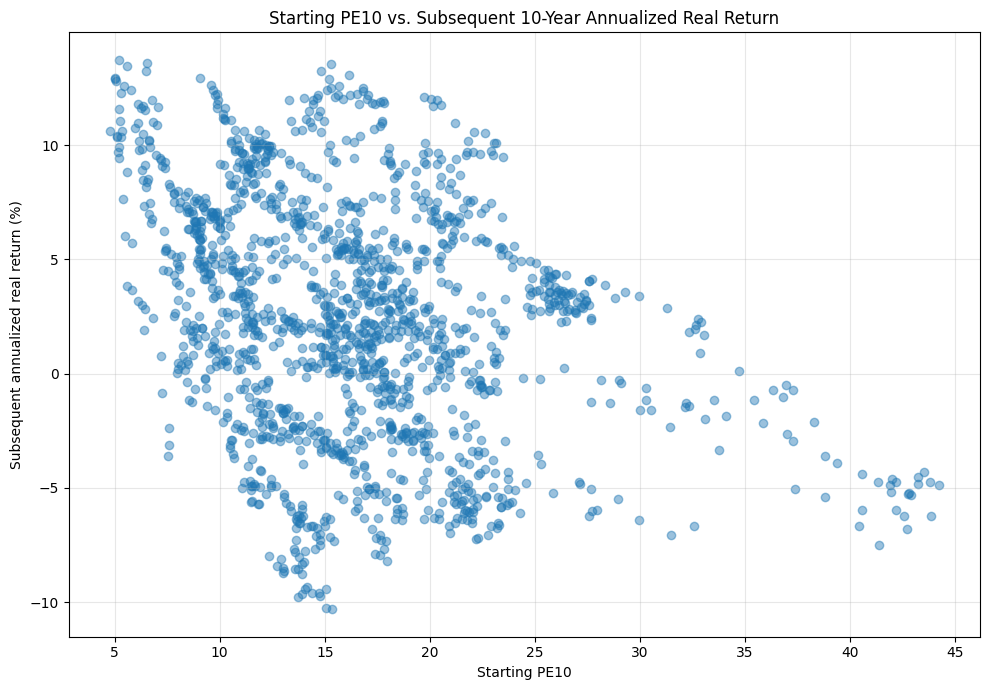

In [25]:
valuation_return = viz_df[["pe10", "real_price"]].copy()
valuation_return["future_10y_real_return"] = (
    (valuation_return["real_price"].shift(-120) / valuation_return["real_price"]) ** (1 / 10) - 1
)
valuation_return = valuation_return.dropna()

plt.figure(figsize=(10, 7))
plt.scatter(
    valuation_return["pe10"],
    valuation_return["future_10y_real_return"] * 100,
    alpha=0.45
)
plt.title("Starting PE10 vs. Subsequent 10-Year Annualized Real Return")
plt.xlabel("Starting PE10")
plt.ylabel("Subsequent annualized real return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.17 Interest rates versus PE10


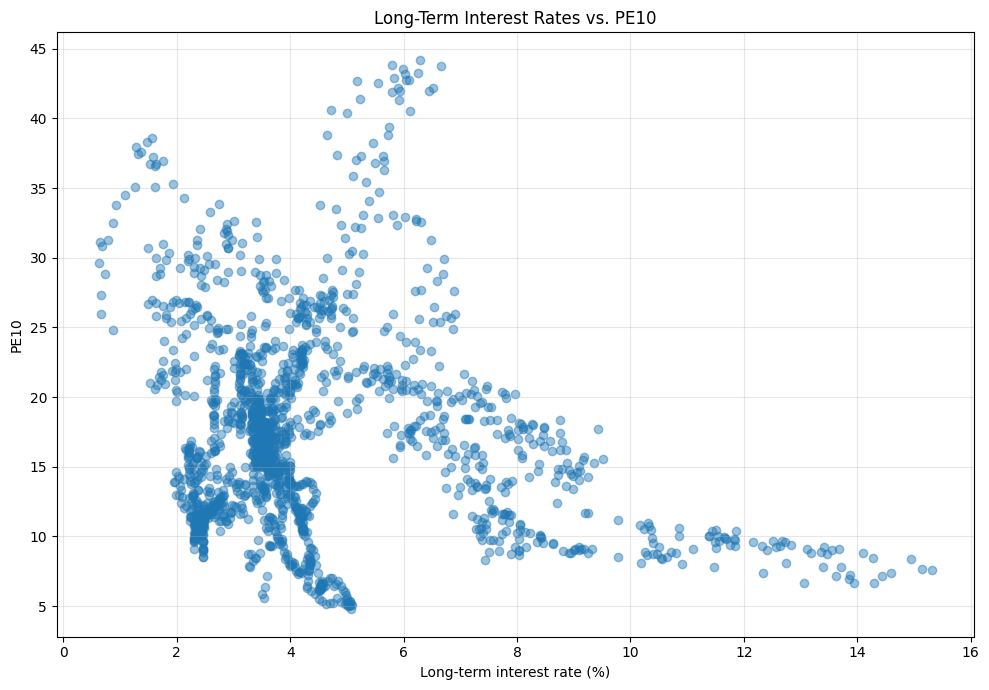

In [26]:
rate_pe10 = viz_df.dropna(subset=["long_interest_rate", "pe10"])
plt.figure(figsize=(10, 7))
plt.scatter(rate_pe10["long_interest_rate"], rate_pe10["pe10"], alpha=0.45)
plt.title("Long-Term Interest Rates vs. PE10")
plt.xlabel("Long-term interest rate (%)")
plt.ylabel("PE10")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.18 Real earnings versus real price



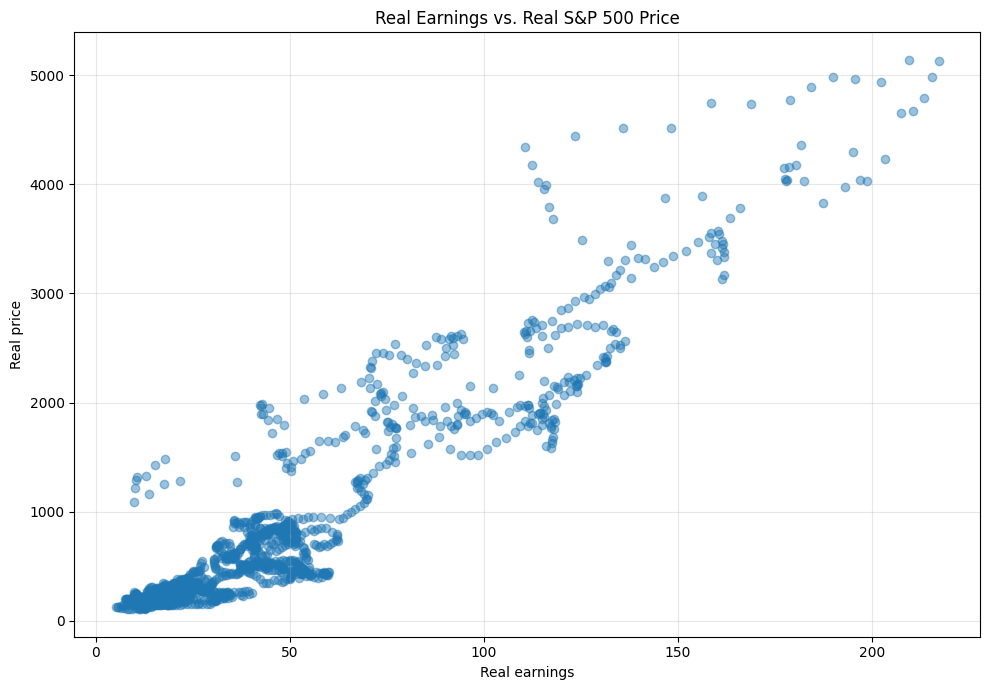

In [27]:
earnings_price = viz_df.dropna(subset=["real_earnings", "real_price"])
plt.figure(figsize=(10, 7))
plt.scatter(earnings_price["real_earnings"], earnings_price["real_price"], alpha=0.45)
plt.title("Real Earnings vs. Real S&P 500 Price")
plt.xlabel("Real earnings")
plt.ylabel("Real price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.19 Correlation heatmap


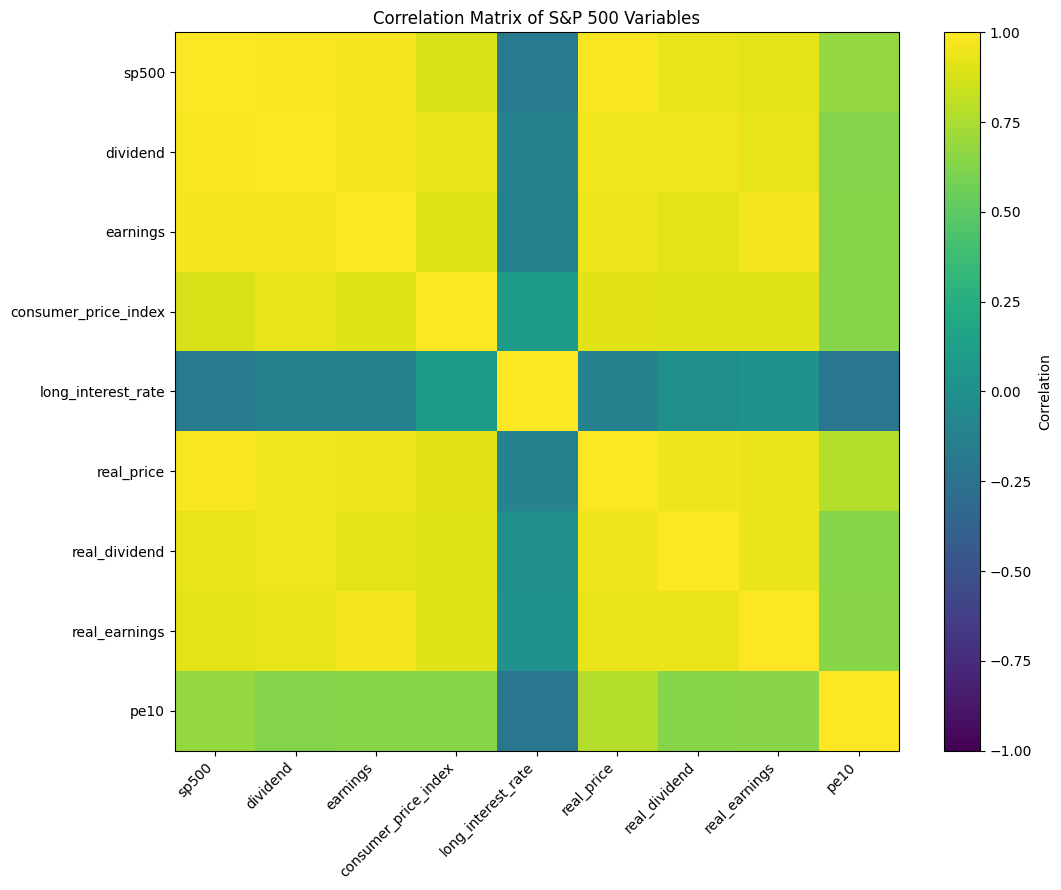

In [28]:
corr_columns = [
    "sp500", "dividend", "earnings", "consumer_price_index",
    "long_interest_rate", "real_price", "real_dividend",
    "real_earnings", "pe10"
]
correlation = viz_df[corr_columns].corr()

plt.figure(figsize=(11, 9))
image = plt.imshow(correlation, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(image, label="Correlation")
plt.xticks(range(len(corr_columns)), corr_columns, rotation=45, ha="right")
plt.yticks(range(len(corr_columns)), corr_columns)
plt.title("Correlation Matrix of S&P 500 Variables")
plt.tight_layout()
plt.show()

### 7.20 Boxplot of annual real returns by decade


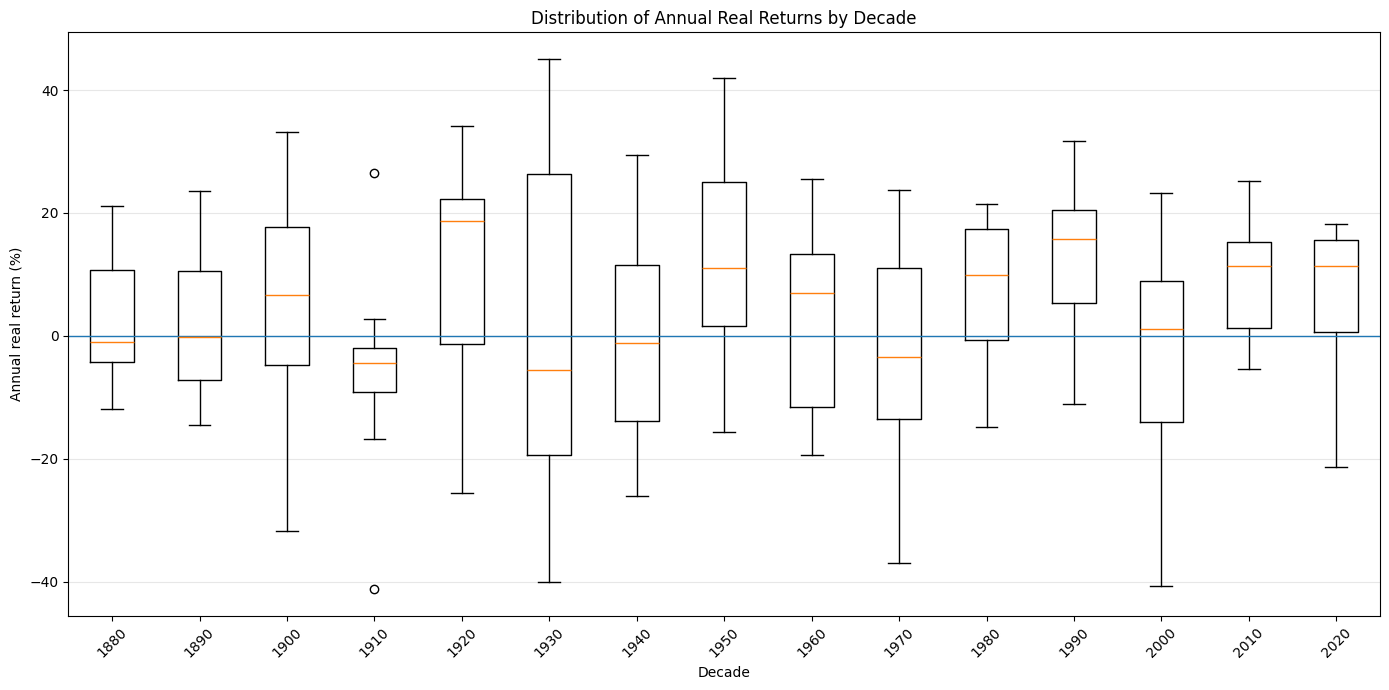

In [29]:
annual_box = annual.copy()
annual_box["decade_label"] = annual_box["decade"].astype(str)
decades = sorted(annual_box["decade_label"].unique())
box_data = [
    annual_box.loc[annual_box["decade_label"] == decade, "real_return"] * 100
    for decade in decades
]

plt.figure(figsize=(14, 7))
plt.boxplot(box_data, tick_labels=decades, showfliers=True)
plt.axhline(0, linewidth=1)
plt.title("Distribution of Annual Real Returns by Decade")
plt.xlabel("Decade")
plt.ylabel("Annual real return (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 7.21 Summary statistics table for key measures


In [30]:
summary_statistics = viz_df[[
    "sp500", "real_price", "dividend", "earnings",
    "consumer_price_index", "long_interest_rate", "pe10"
]].describe().T.round(2)

summary_statistics

,count,mean,std,min,25%,50%,75%,max
sp500,1709.0,396.13,812.89,3.81,8.70,24.78,269.10,4674.77
real_price,1709.0,781.06,919.61,107.37,223.04,358.93,846.28,5140.59
dividend,1709.0,7.99,13.98,0.18,0.47,1.43,8.76,68.71
earnings,1709.0,18.80,35.47,0.16,0.67,2.51,16.12,197.91
consumer_price_index,1709.0,68.76,81.02,6.28,11.10,26.50,115.40,305.11
long_interest_rate,1709.0,4.47,2.37,0.62,3.12,3.69,5.00,15.32
pe10,1709.0,17.38,7.18,4.78,11.95,16.46,21.11,44.20


### Visualization notes

- Nominal values reflect the prices recorded at each date; real values adjust for inflation.
- Return charts are price-return measures and do not include reinvested dividends unless a total-return series is constructed separately.
- The PE10 versus future-return chart is descriptive and does not by itself prove causation.
- The first and last observations removed during cleaning are not included in these visualizations.


# 8. Data Wrangling for the Research Question

The research question asks whether the **starting PE10 ratio predicts subsequent 5- and 10-year inflation-adjusted S&P 500 returns**, and whether that relationship changes across interest-rate regimes.

The cleaned monthly data must therefore be transformed into a modeling dataset. The following steps are used:

- **Re-code values:** Long-term interest rates are converted into low-, medium-, and high-rate regimes.
- **Weights:** No survey or population weights are needed because each row is one monthly market observation. All observations initially receive equal weight.
- **New columns:** Calendar variables, valuation measures, inflation and growth rates, and forward 5- and 10-year real returns are created.
- **Split columns:** No existing column contains multiple variables, so no columns need to be split.
- **Standardization:** Continuous predictors are standardized within the modeling pipelines for models that are affected by scale.
- **Subsets:** Separate complete-case samples are created for the 5-year and 10-year analyses.
- **Outliers:** Historically extreme observations are retained because they represent real market events. For prediction models, predictor values are winsorized at the 1st and 99th percentiles using thresholds learned only from the training data.


In [31]:
# Create a separate wrangled dataframe so the original cleaned dataframe remains unchanged.
model_df = df.copy().sort_values("date").reset_index(drop=True)

# Calendar variables.
model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["decade"] = (model_df["year"] // 10) * 10

# Valuation and economic variables.
model_df["dividend_yield"] = model_df["dividend"] / model_df["sp500"]
model_df["earnings_yield"] = model_df["earnings"] / model_df["sp500"]

# Backward-looking information available at the start of each observation.
model_df["inflation_12m"] = model_df["consumer_price_index"].pct_change(12)
model_df["real_earnings_growth_12m"] = model_df["real_earnings"].pct_change(12)
model_df["real_dividend_growth_12m"] = model_df["real_dividend"].pct_change(12)
model_df["real_price_momentum_12m"] = model_df["real_price"].pct_change(12)

# Forward annualized inflation-adjusted price returns.
# These are the outcomes to be predicted from information known at the starting date.
for years in (5, 10):
    months = years * 12
    model_df[f"forward_{years}y_real_return"] = (
        (model_df["real_price"].shift(-months) / model_df["real_price"]) ** (1 / years)
        - 1
    )

# Re-code interest rates into three equally sized historical regimes.
model_df["interest_rate_regime"] = pd.qcut(
    model_df["long_interest_rate"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("Wrangled shape:", model_df.shape)
model_df[[
    "date", "pe10", "long_interest_rate", "interest_rate_regime",
    "forward_5y_real_return", "forward_10y_real_return"
]].head()

Wrangled shape: (1709, 22)


,date,pe10,long_interest_rate,interest_rate_regime,forward_5y_real_return,forward_10y_real_return
0,1881-02-01,18.15,3.69,Medium,0.004483,-0.004403
1,1881-03-01,18.27,3.69,Medium,0.000418,-0.008555
2,1881-04-01,17.95,3.68,Medium,0.002760,-0.005176
3,1881-05-01,18.87,3.67,Medium,-0.007012,-0.009756
4,1881-06-01,19.03,3.67,Medium,0.001985,-0.010605


## 8.1 Validate the newly created variables

Forward returns are necessarily unavailable near the end of the dataset because the required future 5- or 10-year period has not yet occurred. These rows are not errors; they are excluded only from the corresponding model.


In [32]:
wrangling_summary = pd.DataFrame({
    "data_type": model_df.dtypes.astype(str),
    "missing_count": model_df.isna().sum(),
    "unique_values": model_df.nunique(dropna=True)
})

wrangling_summary.loc[[
    "pe10",
    "interest_rate_regime",
    "forward_5y_real_return",
    "forward_10y_real_return"
]]


,data_type,missing_count,unique_values
pe10,float64,0,1200
interest_rate_regime,category,0,3
forward_5y_real_return,float64,60,1649
forward_10y_real_return,float64,120,1589


# 9. Hypothesis Testing

### Hypotheses

For each return horizon:

- **Null hypothesis:** Mean subsequent real S&P 500 returns are equal across low-, medium-, and high-interest-rate regimes.
- **Alternative hypothesis:** At least one interest-rate regime has a different mean subsequent real return.

A one-way ANOVA is reported as the main test. Because financial returns may violate normality and equal-variance assumptions, a nonparametric Kruskal-Wallis test is also included as a robustness check. A statistically significant test shows an association between rate regimes and future returns; it does not establish causation.


In [33]:
from scipy import stats

hypothesis_results = []

for years in (5, 10):
    outcome = f"forward_{years}y_real_return"
    test_df = model_df.dropna(subset=[outcome, "interest_rate_regime"]).copy()

    groups = [
        group[outcome].to_numpy()
        for _, group in test_df.groupby("interest_rate_regime", observed=True)
    ]

    anova = stats.f_oneway(*groups)
    kruskal = stats.kruskal(*groups)

    # Assumption diagnostics.
    levene = stats.levene(*groups, center="median")

    hypothesis_results.append({
        "horizon": f"{years}-year",
        "observations": len(test_df),
        "anova_F": anova.statistic,
        "anova_p": anova.pvalue,
        "kruskal_H": kruskal.statistic,
        "kruskal_p": kruskal.pvalue,
        "levene_p": levene.pvalue
    })

hypothesis_results = pd.DataFrame(hypothesis_results)
hypothesis_results


,horizon,observations,anova_F,anova_p,kruskal_H,kruskal_p,levene_p
0,5-year,1649,7.518294,5.619142e-04,29.986511,3.079724e-07,4.371234e-03
1,10-year,1589,66.920303,1.253956e-28,119.509075,1.119268e-26,1.367727e-17


In [34]:
# Mean forward real returns by interest-rate regime.
regime_means = (
    model_df
    .groupby("interest_rate_regime", observed=True)[
        ["forward_5y_real_return", "forward_10y_real_return"]
    ]
    .agg(["mean", "median", "std", "count"])
)

regime_means


forward_5y_real_return                            \
                                       mean    median       std count   
interest_rate_regime                                                    
Low                                0.035845  0.050403  0.074938   529   
Medium                             0.017414  0.016980  0.079232   551   
High                               0.024987  0.016122  0.080762   569   

                     forward_10y_real_return                            
                                        mean    median       std count  
interest_rate_regime                                                    
Low                                 0.037112  0.033462  0.048347   469  
Medium                              0.003389  0.011990  0.042101   551  
High                                0.030521  0.039478  0.058300   569

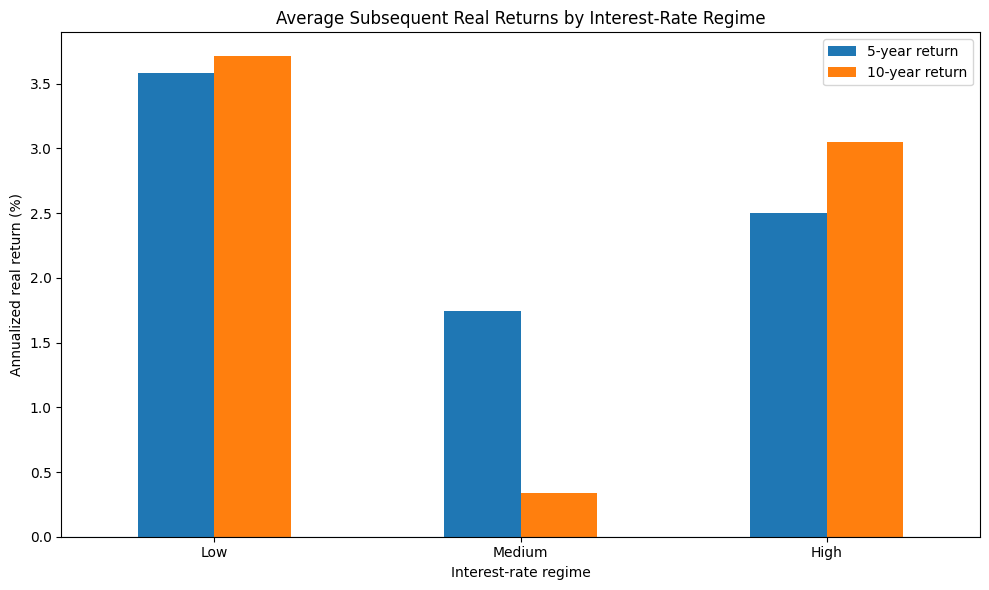

In [35]:
import matplotlib.pyplot as plt

plot_means = (
    model_df.groupby("interest_rate_regime", observed=True)[
        ["forward_5y_real_return", "forward_10y_real_return"]
    ].mean() * 100
)

ax = plot_means.plot(kind="bar", figsize=(10, 6))
ax.set_title("Average Subsequent Real Returns by Interest-Rate Regime")
ax.set_xlabel("Interest-rate regime")
ax.set_ylabel("Annualized real return (%)")
ax.legend(["5-year return", "10-year return"])
ax.axhline(0, linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 10. Predictive Modeling

This is a **regression problem** because the outcomes—future 5-year and 10-year annualized real returns—are continuous.

The models compared are:

1. **Baseline mean model:** Predicts the training-set mean for every observation.
2. **Linear regression:** Provides an interpretable estimate of the relationship between predictors and future returns.
3. **Ridge regression:** Reduces instability caused by correlated predictors.
4. **Random forest regression:** Captures nonlinear relationships and interactions.
5. **Gradient boosting regression:** Builds a sequence of trees to model complex patterns.

A chronological split is used instead of a random split: the earliest 80% of observations form the training set and the latest 20% form the test set. This better represents the real forecasting task and prevents future observations from leaking into the past.

Because this is regression, **precision, recall, and F1 score are not appropriate**. Models are evaluated using mean absolute error (MAE), root mean squared error (RMSE), and R-squared.


In [36]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

class TrainWinsorizer(BaseEstimator, TransformerMixin):
    """Clip each numeric feature to training-set quantile limits."""
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

numeric_features = [
    "pe10",
    "long_interest_rate",
    "dividend_yield",
    "earnings_yield",
    "inflation_12m",
    "real_earnings_growth_12m",
    "real_dividend_growth_12m",
    "real_price_momentum_12m",
]

categorical_features = ["interest_rate_regime"]

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorize", TrainWinsorizer()),
    ("scale", StandardScaler()),
])

numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorize", TrainWinsorizer()),
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

scaled_preprocessor = ColumnTransformer([
    ("numeric", numeric_scaled, numeric_features),
    ("categorical", categorical, categorical_features),
])

tree_preprocessor = ColumnTransformer([
    ("numeric", numeric_tree, numeric_features),
    ("categorical", categorical, categorical_features),
])

models = {
    "Baseline mean": Pipeline([
        ("preprocess", scaled_preprocessor),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "Linear regression": Pipeline([
        ("preprocess", scaled_preprocessor),
        ("model", LinearRegression()),
    ]),
    "Ridge regression": Pipeline([
        ("preprocess", scaled_preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]),
    "Random forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=6,
            min_samples_leaf=8,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    "Gradient boosting": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=8,
            random_state=42,
        )),
    ]),
}

In [37]:
def chronological_split(data, outcome, train_fraction=0.80):
    required = numeric_features + categorical_features + [outcome, "date"]
    sample = data[required].dropna(subset=[outcome]).sort_values("date").reset_index(drop=True)

    split_index = int(len(sample) * train_fraction)
    train = sample.iloc[:split_index].copy()
    test = sample.iloc[split_index:].copy()

    X_train = train[numeric_features + categorical_features]
    y_train = train[outcome]
    X_test = test[numeric_features + categorical_features]
    y_test = test[outcome]

    return train, test, X_train, X_test, y_train, y_test


all_results = []
fitted_models = {}
test_sets = {}

for years in (5, 10):
    outcome = f"forward_{years}y_real_return"
    train, test, X_train, X_test, y_train, y_test = chronological_split(
        model_df, outcome
    )

    test_sets[years] = (test, X_test, y_test)

    print(
        f"{years}-year model: "
        f"{len(train)} training observations through {train['date'].max().date()}, "
        f"{len(test)} test observations beginning {test['date'].min().date()}."
    )

    for model_name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        fitted_models[(years, model_name)] = pipeline

        all_results.append({
            "horizon": f"{years}-year",
            "model": model_name,
            "MAE_percentage_points": mean_absolute_error(y_test, predictions) * 100,
            "RMSE_percentage_points": mean_squared_error(
                y_test, predictions
            ) ** 0.5 * 100,
            "R_squared": r2_score(y_test, predictions),
        })

model_results = pd.DataFrame(all_results).sort_values(
    ["horizon", "RMSE_percentage_points"]
)

model_results

5-year model: 1319 training observations through 1990-12-01, 330 test observations beginning 1991-01-01.
10-year model: 1271 training observations through 1986-12-01, 318 test observations beginning 1987-01-01.


,horizon,model,MAE_percentage_points,RMSE_percentage_points,R_squared
5,10-year,Baseline mean,5.160281,6.045359,-0.535124
8,10-year,Random forest,7.502291,8.237410,-1.850235
9,10-year,Gradient boosting,8.564418,9.200176,-2.555426
7,10-year,Ridge regression,8.831248,9.316253,-2.645708
6,10-year,Linear regression,9.016482,9.478983,-2.774182
0,5-year,Baseline mean,7.622432,8.773208,-0.238728
3,5-year,Random forest,9.614818,11.760497,-1.225925
2,5-year,Ridge regression,11.451902,13.106213,-1.764481
1,5-year,Linear regression,11.695176,13.297741,-1.845869
4,5-year,Gradient boosting,12.258535,13.929601,-2.122745


In [38]:
# Identify the best model for each horizon based on test RMSE.
best_models = (
    model_results.sort_values("RMSE_percentage_points")
    .groupby("horizon", as_index=False)
    .first()
)

best_models

,horizon,model,MAE_percentage_points,RMSE_percentage_points,R_squared
0,10-year,Baseline mean,5.160281,6.045359,-0.535124
1,5-year,Baseline mean,7.622432,8.773208,-0.238728


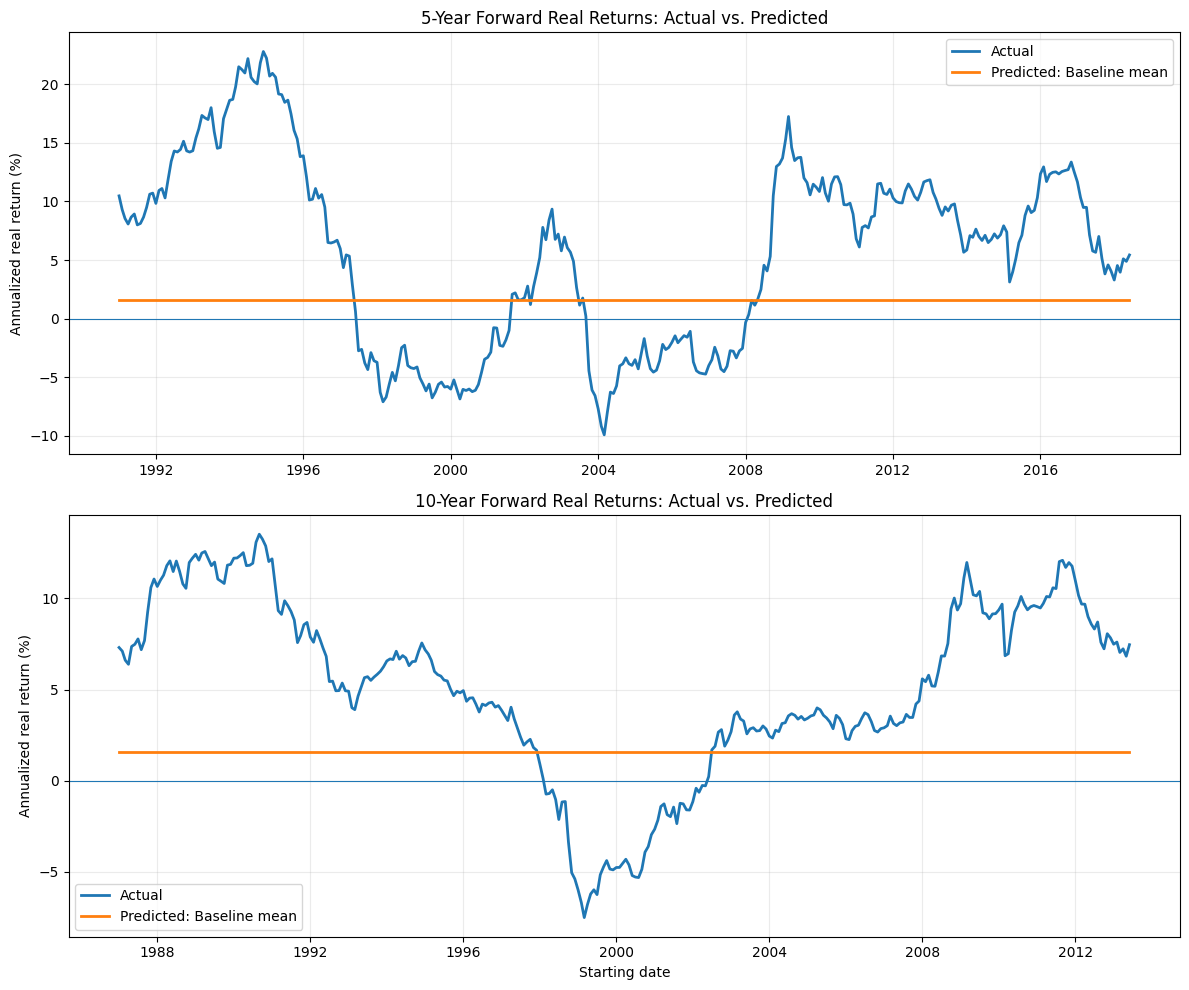

In [39]:
# Compare actual and predicted returns for the best model at each horizon.
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

for ax, years in zip(axes, (5, 10)):
    horizon = f"{years}-year"
    best_name = best_models.loc[
        best_models["horizon"].eq(horizon), "model"
    ].iloc[0]

    test, X_test, y_test = test_sets[years]
    best_pipeline = fitted_models[(years, best_name)]
    predictions = best_pipeline.predict(X_test)

    ax.plot(test["date"], y_test.to_numpy() * 100, label="Actual", linewidth=2)
    ax.plot(test["date"], predictions * 100, label=f"Predicted: {best_name}", linewidth=2)
    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"{years}-Year Forward Real Returns: Actual vs. Predicted")
    ax.set_ylabel("Annualized real return (%)")
    ax.legend()
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Starting date")
plt.tight_layout()
plt.show()


## 10.1 Which variables are most useful?

Permutation importance measures how much test-set prediction error increases when one predictor is randomly shuffled. A larger value indicates that the trained model relied more heavily on that variable. This is predictive importance, not proof of causality.

In [40]:
importance_rows = []

for years in (5, 10):
    horizon = f"{years}-year"
    best_name = best_models.loc[
        best_models["horizon"].eq(horizon), "model"
    ].iloc[0]

    _, X_test, y_test = test_sets[years]
    best_pipeline = fitted_models[(years, best_name)]

    importance = permutation_importance(
        best_pipeline,
        X_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=20,
        random_state=42,
        n_jobs=-1,
    )

    for feature, mean_value, std_value in zip(
        X_test.columns,
        importance.importances_mean,
        importance.importances_std,
    ):
        importance_rows.append({
            "horizon": horizon,
            "model": best_name,
            "feature": feature,
            "importance_mean": mean_value,
            "importance_std": std_value,
        })

feature_importance = pd.DataFrame(importance_rows).sort_values(
    ["horizon", "importance_mean"],
    ascending=[True, False],
)

feature_importance

,horizon,model,feature,importance_mean,importance_std
9,10-year,Baseline mean,pe10,0.0,0.0
10,10-year,Baseline mean,long_interest_rate,0.0,0.0
11,10-year,Baseline mean,dividend_yield,0.0,0.0
12,10-year,Baseline mean,earnings_yield,0.0,0.0
13,10-year,Baseline mean,inflation_12m,0.0,0.0
14,10-year,Baseline mean,real_earnings_growth_12m,0.0,0.0
15,10-year,Baseline mean,real_dividend_growth_12m,0.0,0.0
16,10-year,Baseline mean,real_price_momentum_12m,0.0,0.0
17,10-year,Baseline mean,interest_rate_regime,0.0,0.0
0,5-year,Baseline mean,pe10,0.0,0.0


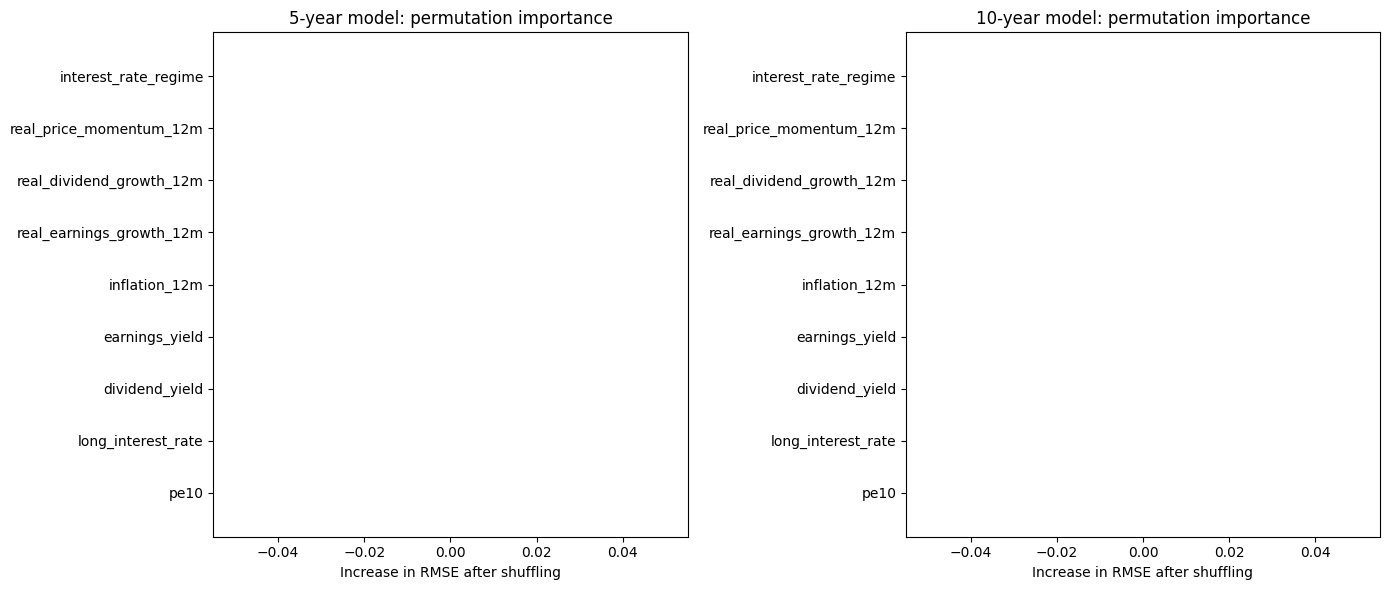

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, years in zip(axes, (5, 10)):
    horizon = f"{years}-year"
    chart_data = (
        feature_importance[feature_importance["horizon"].eq(horizon)]
        .sort_values("importance_mean")
    )

    ax.barh(chart_data["feature"], chart_data["importance_mean"])
    ax.set_title(f"{horizon} model: permutation importance")
    ax.set_xlabel("Increase in RMSE after shuffling")

plt.tight_layout()
plt.show()

# 11. Interpretation, Assumptions, and Limitations

Run the cells above, then interpret the printed tables using the following framework:

- If the ANOVA or Kruskal-Wallis p-value is below the selected significance level, reject the null hypothesis that future mean returns are identical across all interest-rate regimes.
- Compare each predictive model against the baseline. A model is useful only if it lowers out-of-sample MAE and RMSE and improves R-squared.
- Negative test R-squared means the model performed worse than simply predicting the training-set mean.
- Examine whether PE10 is among the most important predictors and whether adding rates and economic variables improves predictions over a simple linear model.
- The chronological test period may represent a different economic era from the training period, making it a difficult but realistic assessment of model stability.

### Assumptions and limitations

1. **No causal claim:** Regression and feature importance show association and predictive usefulness, not causation.
2. **Overlapping outcomes:** Monthly 5- and 10-year forward returns overlap heavily, creating serial dependence.
3. **Structural change:** Market composition, accounting standards, monetary policy, taxation, and investor behavior changed across the historical sample.
4. **Reconstructed early data:** Observations from before the modern S&P 500 are historical reconstructions.
5. **Price return rather than total return:** The outcome uses inflation-adjusted price changes and does not add reinvested dividends.
6. **Regime definition:** Terciles are sample-based statistical categories, not official monetary-policy regimes.
7. **Outliers:** Extreme historical episodes are kept in the analysis; only predictor values supplied to models are clipped to training-set 1st and 99th percentile thresholds.
8. **Model selection:** Results depend on the chosen predictors, hyperparameters, split date, and evaluation period.
9. **Look-ahead protection:** All transformations that estimate medians, clipping thresholds, scaling parameters, and model coefficients are fitted using training data only.

- **Do any values need to be re-coded?** Yes. Interest rates are re-coded into low, medium, and high regimes.
- **Are weights needed?** No. This is not survey data, and each row is one monthly observation.
- **Are new columns needed?** Yes. Forward 5- and 10-year real returns, yields, growth rates, momentum, calendar fields, and rate regimes are created.
- **Do columns need to be split?** No. Each original column already contains one variable.
- **Does the data need to be standardized?** Yes, for linear and ridge regression. Standardization is learned from training data only.
- **Are subsets needed?** Yes. Separate complete-case samples are used for each return horizon, followed by chronological training and test subsets.
- **Should outliers be removed?** No historical observations are deleted merely for being extreme. Predictor values are winsorized within the model pipeline to reduce excessive influence.
- **What analysis is used?** Both hypothesis testing and continuous-outcome prediction are used.
- **Which model is most appropriate?** Regression models are appropriate because future returns are continuous.
- **How is model performance measured?** Test-set MAE, RMSE, and R-squared are used. F1, precision, and recall are classification metrics and are therefore not used.